In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [4]:
from google.colab import files

uploaded = files.upload()

Saving stock_price_lstm_dataset.csv to stock_price_lstm_dataset.csv


In [5]:
df = pd.read_csv(list(uploaded.keys())[0])

df.head()

,Date,Open,High,Low,Close,Volume
0,2023-01-01,152.69,153.63,150.74,151.42,4398888
1,2023-01-02,151.96,152.11,149.84,151.12,1395596
2,2023-01-03,153.03,153.83,151.13,152.97,2931129
3,2023-01-04,156.69,157.56,156.37,157.30,2100720
4,2023-01-05,157.37,159.28,155.35,156.72,3105327


In [6]:
print(df.shape)
print(df.columns)
print(df.info())

(1000, 6)
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1000 non-null   object 
 1   Open    1000 non-null   float64
 2   High    1000 non-null   float64
 3   Low     1000 non-null   float64
 4   Close   1000 non-null   float64
 5   Volume  1000 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 47.0+ KB
None


In [7]:
data = df[['Close']].copy()

data.head()
print(data.isnull().sum())
data = data.dropna()

Close    0
dtype: int64


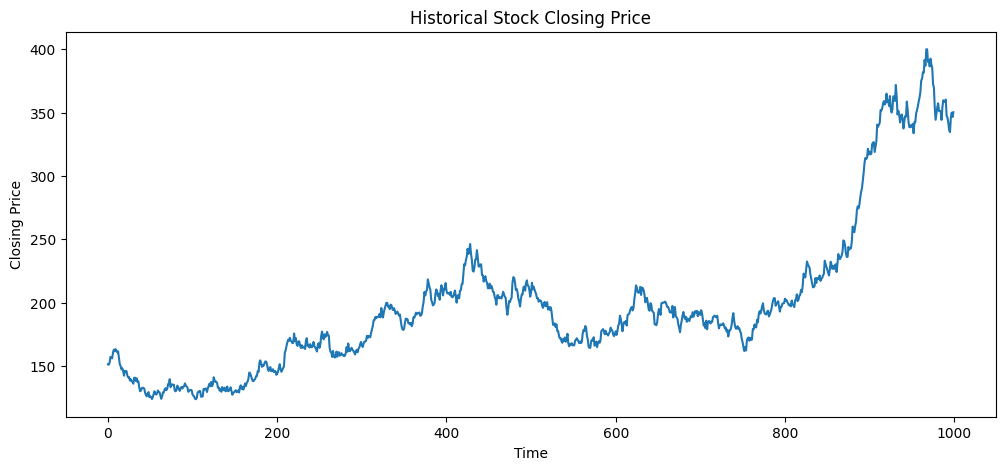

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(data['Close'])

plt.title('Historical Stock Closing Price')
plt.xlabel('Time')
plt.ylabel('Closing Price')

plt.show()

In [9]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(data)

In [10]:
train_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

Training samples: 800
Testing samples: 200


In [11]:
def create_sequences(data, time_steps=60):
    X = []
    y = []

    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

In [12]:
X_train, y_train = create_sequences(train_data, 60)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (740, 60)
y_train shape: (740,)


In [13]:
# Include previous 60 training observations
# so that the first test prediction has enough historical data

test_input = np.concatenate((train_data[-60:], test_data))

X_test, y_test = create_sequences(test_input, 60)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (200, 60)
y_test shape: (200,)


In [15]:

X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("Final X_train shape:", X_train.shape)
print("Final X_test shape:", X_test.shape)

Final X_train shape: (740, 60, 1)
Final X_test shape: (200, 60, 1)


In [16]:
model = Sequential()

model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        units=50,
        return_sequences=False
    )
)

model.add(Dropout(0.2))

model.add(Dense(25))

model.add(Dense(1))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0114 - val_loss: 0.0017
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0017 - val_loss: 7.1002e-04
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0011 - val_loss: 6.8164e-04
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.0010 - val_loss: 9.6702e-04
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 8.8447e-04 - val_loss: 7.1840e-04
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 9.4459e-04 - val_loss: 7.9311e-04
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 8.9841e-04 - val_loss: 6.6198e-04
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 7.3896e-04 - val_loss: 5.9112e-04
Epoch 9/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 7.2800e-04 - val_loss: 6.3120e-04
Epoch 10/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 7.2084e-04 - val_loss: 6.4048e-04
Epoch 11/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 7.4234e-04 - val_loss: 5.62

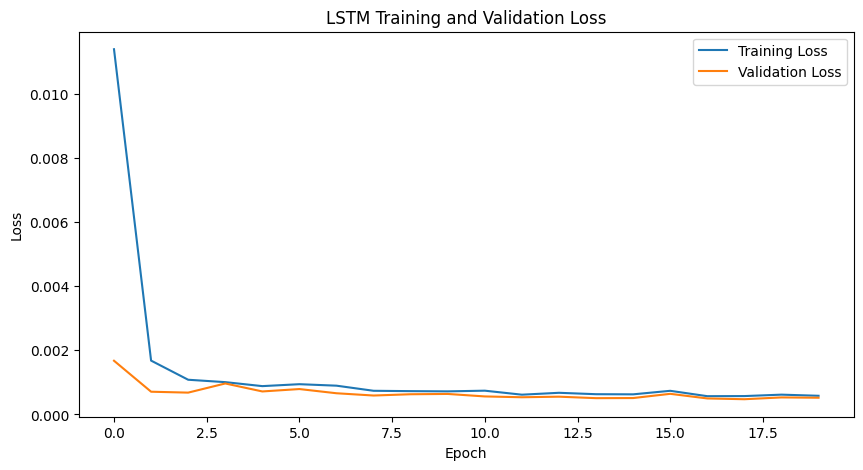

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [20]:
predictions = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predictions)

actual_prices = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 190ms/step


In [21]:
comparison = pd.DataFrame({
    'Actual Price': actual_prices.flatten(),
    'Predicted Price': predicted_prices.flatten()
})

comparison.head(10)

,Actual Price,Predicted Price
0,203.22,194.882996
1,201.44,195.403168
2,201.89,195.962189
3,200.32,196.536713
4,198.86,196.927200
5,197.85,197.040115
6,198.75,196.882751
7,197.14,196.652985
8,201.75,196.254333
9,198.62,196.198608


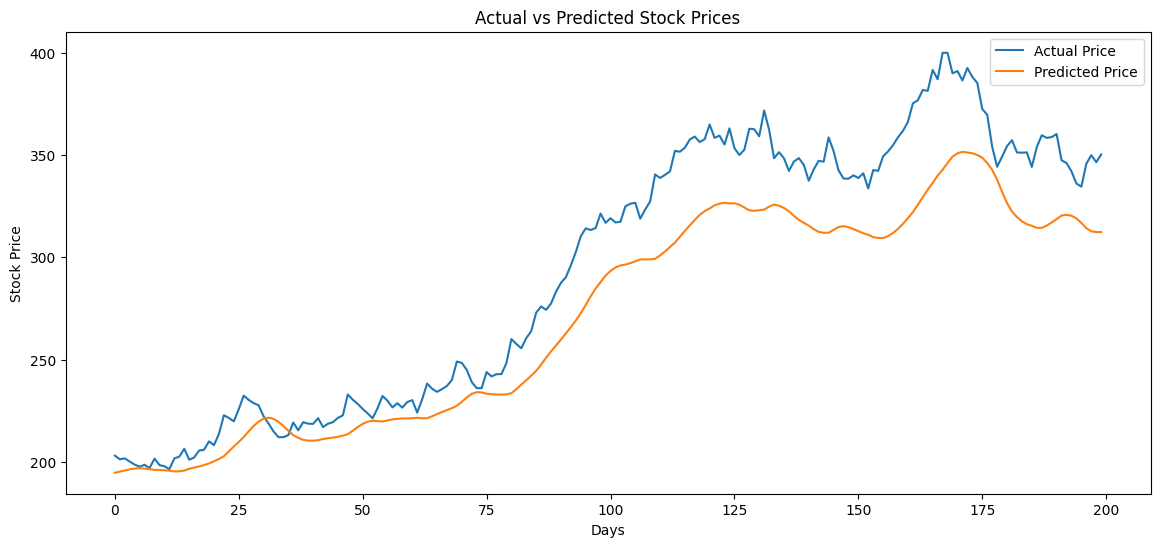

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(
    actual_prices,
    label='Actual Price'
)

plt.plot(
    predicted_prices,
    label='Predicted Price'
)

plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Days')
plt.ylabel('Stock Price')

plt.legend()
plt.show()

In [23]:
rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        predicted_prices
    )
)

mae = mean_absolute_error(
    actual_prices,
    predicted_prices
)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 27.191518918315428
MAE: 23.080303906250002


In [24]:
mape = np.mean(
    np.abs(
        (actual_prices - predicted_prices) /
        actual_prices
    )
) * 100

print("MAPE:", mape, "%")

MAPE: 7.212935762525455 %


In [25]:
print("----- Model Performance -----")
print("RMSE :", round(rmse, 4))
print("MAE  :", round(mae, 4))
print("MAPE :", round(mape, 2), "%")

----- Model Performance -----
RMSE : 27.1915
MAE  : 23.0803
MAPE : 7.21 %


In [26]:
last_60_days = scaled_data[-60:]

X_next = last_60_days.reshape(1, 60, 1)

next_prediction = model.predict(X_next)

next_price = scaler.inverse_transform(
    next_prediction
)

print(
    "Predicted next closing price:",
    next_price[0][0]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Predicted next closing price: 312.95633
